# Lab 3

In [9]:
# role_aware_pass_predictor.py
from dataclasses import dataclass, field
from typing import Dict, Tuple, Optional
import json, math, os

PASS_TYPES = ["short", "long", "through", "chip", "cross", "backpass"]
PRESSURE_LEVELS = ["low", "medium", "high"]

def sigmoid(x: float) -> float:
    return 1.0 / (1.0 + math.exp(-x))

def clamp(v, lo=0.0, hi=1.0) -> float:
    return max(lo, min(hi, v))

# ------------------------ Player Skill (Bayesian Beta) ------------------------

@dataclass
class PlayerSkill:
    player_id: str
    a: float = 2.0     # prior successes + 1 (mild prior)
    b: float = 2.0     # prior failures + 1
    # Optional per-pass-type subskills: pass_type -> (a, b)
    subskills: Dict[str, Tuple[float, float]] = field(default_factory=dict)

    @property
    def mean(self) -> float:
        return self.a / (self.a + self.b)

    @property
    def var(self) -> float:
        A, B = self.a, self.b
        return (A * B) / (((A + B) ** 2) * (A + B + 1))

    @property
    def n_obs(self) -> int:
        # Effective observations under Beta prior
        return int((self.a - 1) + (self.b - 1))

    def mean_for_type(self, pass_type: Optional[str]) -> float:
        if not pass_type or pass_type not in self.subskills:
            return self.mean
        A, B = self.subskills[pass_type]
        return A / (A + B)

    def var_for_type(self, pass_type: Optional[str]) -> float:
        if not pass_type or pass_type not in self.subskills:
            return self.var
        A, B = self.subskills[pass_type]
        return (A * B) / (((A + B) ** 2) * (A + B + 1))

    def update(self, success: bool, pass_type: Optional[str] = None):
        # Update subskill for this pass type
        if pass_type and pass_type in PASS_TYPES:
            A, B = self.subskills.get(pass_type, (2.0, 2.0))
            if success: A += 1.0
            else: B += 1.0
            self.subskills[pass_type] = (A, B)
        # Always update overall
        if success: self.a += 1.0
        else: self.b += 1.0

class SkillStore:
    """
    Minimal JSON-backed skill storage (replace with DB if needed).
    """
    def __init__(self, path: str = "player_skills.json"):
        self.path = path
        self.players: Dict[str, PlayerSkill] = {}
        self._load()

    def _load(self):
        if os.path.exists(self.path):
            with open(self.path, "r", encoding="utf-8") as f:
                raw = json.load(f)
            for pid, rec in raw.items():
                self.players[pid] = PlayerSkill(
                    player_id=pid,
                    a=rec.get("a", 2.0),
                    b=rec.get("b", 2.0),
                    subskills={k: tuple(v) for k, v in rec.get("subskills", {}).items()},
                )

    def _save(self):
        out = {pid: {"a": ps.a, "b": ps.b, "subskills": ps.subskills} for pid, ps in self.players.items()}
        with open(self.path, "w", encoding="utf-8") as f:
            json.dump(out, f, ensure_ascii=False, indent=2)

    def get(self, player_id: str) -> PlayerSkill:
        if player_id not in self.players:
            self.players[player_id] = PlayerSkill(player_id=player_id)
        return self.players[player_id]

    def update(self, player_id: str, success: bool, pass_type: Optional[str] = None):
        ps = self.get(player_id)
        ps.update(success, pass_type)
        self._save()

# ------------------------------- Calibration ---------------------------------

@dataclass
class CalibrationStats:
    # Running Brier score avg (lower is better). Start near prior ~0.25
    brier_sum: float = 0.25
    count: int = 1

    def update(self, prob: float, outcome: bool):
        self.brier_sum += (prob - (1.0 if outcome else 0.0)) ** 2
        self.count += 1

    @property
    def brier(self) -> float:
        return self.brier_sum / max(self.count, 1)

    def confidence(self) -> float:
        # Map Brier in [0, 0.25] to confidence in [1.0, 0.0]
        return clamp(1.0 - (self.brier / 0.25), 0.0, 1.0)

# ----------------------- Role-Aware Pass Success Model -----------------------

@dataclass
class RoleAwarePassPredictor:
    # Interpretable weights (tune offline on your data if available)
    w_bias: float = 0.0
    w_distance: float = -2.0
    w_angle: float = -1.0
    w_defender_prox: float = -2.0   # closer defenders (encoded as higher penalty)
    w_passer_speed: float = 0.8
    w_target_speed: float = 0.6
    w_pressure: float = -1.2
    w_skill_global: float = 2.0
    w_pass_type: Dict[str, float] = field(default_factory=lambda: {
        "short": 0.6, "long": -0.3, "through": 0.2, "chip": -0.1, "cross": -0.2, "backpass": 0.4
    })
    # Defaults (override with your lab roles at init)
    w_passer_role: Dict[str, float] = field(default_factory=lambda: {
        "Defender": -0.1, "Midfielder": 0.2, "Forward": -0.05, "Goalkeeper": -0.3
    })
    w_target_role: Dict[str, float] = field(default_factory=lambda: {
        "Defender": 0.0, "Midfielder": 0.1, "Forward": 0.2, "Goalkeeper": -0.2
    })
    # Pressure encoding
    w_pressure_level: Dict[str, float] = field(default_factory=lambda: {
        "low": 0.2, "medium": 0.0, "high": -0.2
    })
    # Optional role-pair synergy (passer→target)
    w_role_synergy: Dict[Tuple[str, str], float] = field(default_factory=lambda: {
        ("Midfielder", "Forward"): 0.3,
        ("Defender", "Midfielder"): 0.1,
        ("Defender", "Forward"): 0.05,
        ("Goalkeeper", "Defender"): 0.2,
    })

    # Persistent skill + calibration
    skills: SkillStore = field(default_factory=lambda: SkillStore())
    calib: CalibrationStats = field(default_factory=CalibrationStats)

    # Feature normalization (adapt to your tracking)
    norm_cfg: Dict[str, float] = field(default_factory=lambda: {
        "DistanceToTarget_max": 40.0,  # meters
        "AngleToTarget_max": 180.0,    # degrees
        "DefenderProximity_max": 10.0, # meters
        "PasserSpeed_max": 9.0,        # m/s
        "TargetSpeed_max": 9.0,        # m/s
    })

    # ------------- helpers -------------
    def _scale(self, name: str, val: float) -> float:
        m = self.norm_cfg.get(name + "_max", 1.0)
        return clamp(val / m, 0.0, 1.0)

    def _pressure_scalar(self, pressure: Optional[str]) -> float:
        if pressure not in PRESSURE_LEVELS:
            return 0.0
        return self.w_pressure_level[pressure]

    def _encode_roles(self, passer_role: Optional[str], target_role: Optional[str]) -> float:
        s = 0.0
        if passer_role in self.w_passer_role:
            s += self.w_passer_role[passer_role]
        if target_role in self.w_target_role:
            s += self.w_target_role[target_role]
        key = (passer_role, target_role)
        if key in self.w_role_synergy:
            s += self.w_role_synergy[key]
        return s

    def _encode_pass_type(self, pass_type: Optional[str]) -> float:
        if pass_type in self.w_pass_type:
            return self.w_pass_type[pass_type]
        return 0.0

    def _skill_term(self, passer_id: str, pass_type: Optional[str]):
        ps = self.skills.get(passer_id)
        mu = ps.mean_for_type(pass_type)
        var = ps.var_for_type(pass_type)
        n = ps.n_obs
        # Map mean in [0,1] → z in [-1,1]
        z = (mu - 0.5) * 2.0
        return z, var, n

    def _compose_score(self, features: Dict):
        # Normalize inputs
        dist = self._scale("DistanceToTarget", features.get("DistanceToTarget", 0.0))
        angle = self._scale("AngleToTarget", features.get("AngleToTarget", 0.0))
        # Defender proximity: smaller raw value → harder → invert after scaling
        def_prox = self._scale("DefenderProximity", features.get("DefenderProximity", 0.0))
        def_prox = 1.0 - def_prox
        pspeed = self._scale("PasserSpeed", features.get("PasserSpeed", 0.0))
        tspeed = self._scale("TargetSpeed", features.get("TargetSpeed", 0.0))
        pressure_s = self._pressure_scalar(features.get("Pressure"))
        roles_s = self._encode_roles(features.get("PasserRole"), features.get("TargetRole"))
        ptype_s = self._encode_pass_type(features.get("PassType"))
        skill_z, skill_var, n_obs = self._skill_term(features.get("PasserID", "unknown"), features.get("PassType"))

        score = (
            self.w_bias
            + self.w_distance * dist
            + self.w_angle * angle
            + self.w_defender_prox * def_prox
            + self.w_passer_speed * pspeed
            + self.w_target_speed * tspeed
            + self.w_pressure * pressure_s
            + roles_s
            + ptype_s
            + self.w_skill_global * skill_z
        )
        detail = {
            "dist_scaled": dist, "angle_scaled": angle, "defender_prox_scaled_inverted": def_prox,
            "passer_speed_scaled": pspeed, "target_speed_scaled": tspeed,
            "pressure_enc": pressure_s, "roles_score": roles_s, "pass_type_score": ptype_s,
            "skill_z": skill_z, "skill_var": skill_var, "skill_n_obs": n_obs
        }
        return score, detail

    # ------------- public API -------------
    def predict(self, features: Dict, include_confidence: bool = True) -> Dict:
        score, detail = self._compose_score(features)
        prob = sigmoid(score)
        out = {"pass_success_prob": prob, "detail": detail}
        if include_confidence:
            out["confidence"] = self._confidence(detail)
        return out

    def _confidence(self, detail: Dict) -> Dict:
        # (1) Skill confidence (lower Beta var ⇒ higher)
        skill_var = detail["skill_var"]            # ~[0, 0.0625] typical
        skill_conf = clamp(1.0 - (skill_var / 0.0625), 0.0, 1.0)
        # (2) Data confidence (more events ⇒ higher)
        n = max(detail["skill_n_obs"], 0)
        data_conf = clamp(n / 150.0, 0.0, 1.0)     # saturate around 150 events
        # (3) Calibration confidence (better Brier ⇒ higher)
        calib_conf = self.calib.confidence()
        # Combine
        combined = clamp(0.45*skill_conf + 0.35*data_conf + 0.20*calib_conf, 0.0, 1.0)
        label = "Low"
        if combined >= 0.75: label = "High"
        elif combined >= 0.45: label = "Medium"
        return {"score": combined, "label": label,
                "components": {"skill_conf": skill_conf, "data_conf": data_conf, "calibration_conf": calib_conf}}

    def update_after_outcome(self, features: Dict, success: bool):
        """
        Call this once you know the ground-truth outcome of a predicted pass.
        Updates player skill Beta posterior + running calibration.
        """
        passer = features.get("PasserID", "unknown")
        ptype = features.get("PassType")
        pred = self.predict(features, include_confidence=False)["pass_success_prob"]
        self.calib.update(prob=pred, outcome=success)
        self.skills.update(passer, success=success, pass_type=ptype)


Scored preview:
   PasserID PasserRole TargetRole  DistanceToTarget  AngleToTarget  \
0       p_4        ATT        ATT         17.742544       5.780434   
1       p_7        ATT        ATT         14.576420      10.332902   
2       p_7        DEF        ATT         25.993918      22.732858   
3       p_3        ATT        DEF          5.948320      41.593623   
4       p_7        ATT        PLY         29.684943       3.944649   
5       p_6        ATT        ATT         34.900882       2.139050   
6       p_5        ATT        ATT         23.121874       0.334213   
7       p_6        PLY        ATT         22.149590       7.422430   
8       p_6        ATT        ATT         32.087041      23.999848   
9       p_7        PLY        ATT          7.045412      40.033996   
10      p_3        ATT        ATT         26.390395      49.607203   
11      p_1        PLY        ATT         32.576218      28.573164   

    DefenderProximity  PasserSpeed  TargetSpeed  PassType Pressure  \
0  

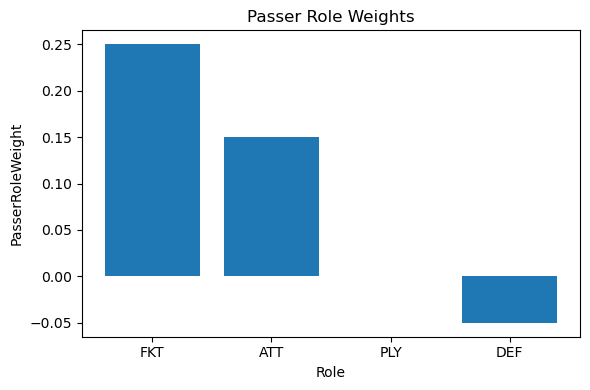

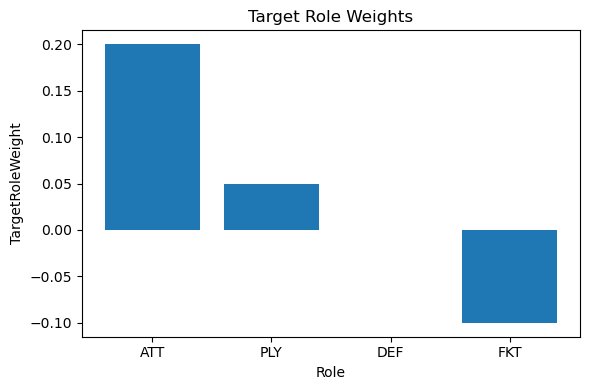

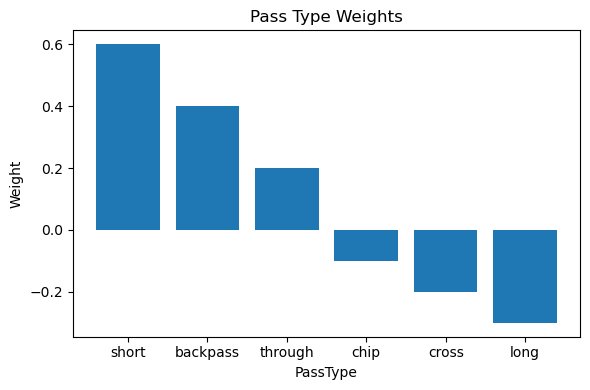

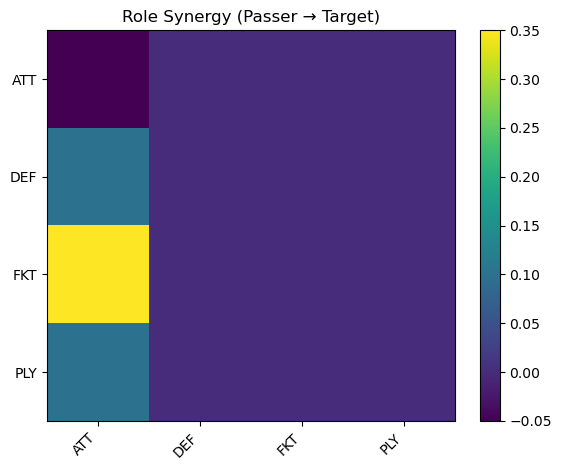

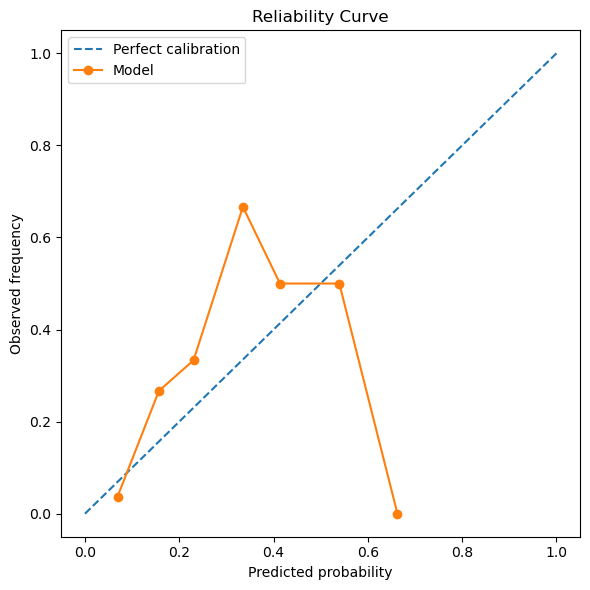

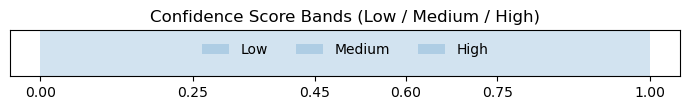

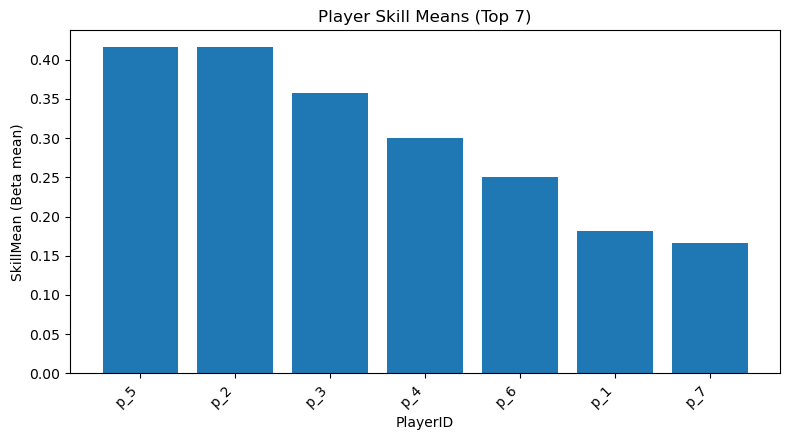

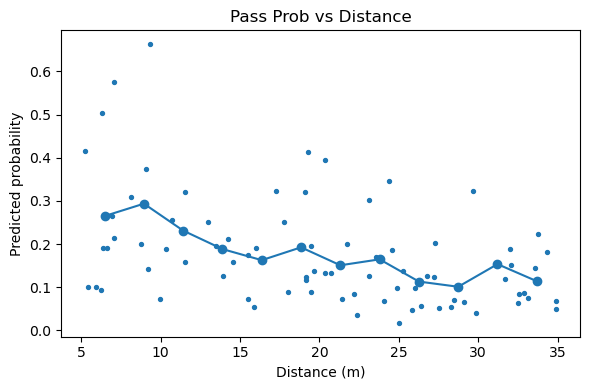

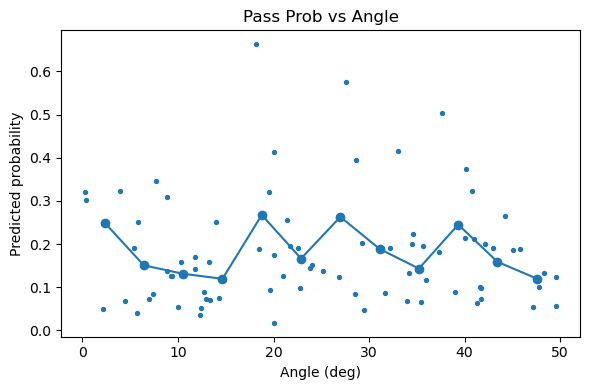

In [12]:
# main_demo.py
# FULL EXAMPLE: batch scoring + skill updates + visualizations (FKT/ATT/DEF/PLY)

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Local import (adjust if needed)
from role_aware_pass_predictor import RoleAwarePassPredictor, SkillStore

# --------------------------------------------------------------------
# 1) Init predictor w/ your roles (FKT, ATT, DEF, PLY) and local skill file
# --------------------------------------------------------------------
skill_store_path = "player_skills.json"  # persisted Beta posteriors
store = SkillStore(path=skill_store_path)

w_passer_role = {"FKT": 0.25, "ATT": 0.15, "DEF": -0.05, "PLY": 0.00}
w_target_role = {"FKT": -0.10, "ATT": 0.20, "DEF": 0.00, "PLY": 0.05}
w_role_synergy = {
    ("FKT", "ATT"): 0.35,
    ("DEF", "ATT"): 0.10,
    ("PLY", "ATT"): 0.10,
    ("ATT", "ATT"): -0.05,
}

predictor = RoleAwarePassPredictor(
    w_passer_role=w_passer_role,
    w_target_role=w_target_role,
    w_role_synergy=w_role_synergy,
    skills=store
)

# --------------------------------------------------------------------
# 2) Batch functions
# --------------------------------------------------------------------
def score_passes(df: pd.DataFrame, predictor: RoleAwarePassPredictor,
                 id_col="PasserID", passer_role_col="PasserRole", target_role_col="TargetRole",
                 dist_col="DistanceToTarget", angle_col="AngleToTarget",
                 defprox_col="DefenderProximity", pspeed_col="PasserSpeed", tspeed_col="TargetSpeed",
                 type_col="PassType", pressure_col="Pressure") -> pd.DataFrame:
    """
    Returns a copy of df with columns:
      - pass_prob: predicted probability of pass success
      - conf_score: numeric confidence [0..1]
      - conf_label: Low/Medium/High
    """
    probs, confs, conf_labels = [], [], []
    for _, r in df.iterrows():
        event = {
            "PasserID": r[id_col],
            "PasserRole": r[passer_role_col],
            "TargetRole": r[target_role_col],
            "DistanceToTarget": float(r[dist_col]),
            "AngleToTarget": float(r[angle_col]),
            "DefenderProximity": float(r[defprox_col]),
            "PasserSpeed": float(r[pspeed_col]),
            "TargetSpeed": float(r[tspeed_col]),
            "PassType": (r[type_col] if type_col in r and pd.notna(r[type_col]) else None),
            "Pressure": (r[pressure_col] if pressure_col in r and pd.notna(r[pressure_col]) else None),
        }
        out = predictor.predict(event, include_confidence=True)
        probs.append(out["pass_success_prob"])
        confs.append(out["confidence"]["score"])
        conf_labels.append(out["confidence"]["label"])

    out_df = df.copy()
    out_df["pass_prob"] = probs
    out_df["conf_score"] = confs
    out_df["conf_label"] = conf_labels
    return out_df


def update_skills_from_outcomes(df_scored: pd.DataFrame, predictor: RoleAwarePassPredictor,
                                outcome_col="PassSuccess",
                                id_col="PasserID", passer_role_col="PasserRole", target_role_col="TargetRole",
                                dist_col="DistanceToTarget", angle_col="AngleToTarget",
                                defprox_col="DefenderProximity", pspeed_col="PasserSpeed", tspeed_col="TargetSpeed",
                                type_col="PassType", pressure_col="Pressure"):
    """
    Reads each row (already scored is fine) and updates the player's Beta skill
    and the model calibration with the observed ground-truth outcome.
    """
    for _, r in df_scored.iterrows():
        event = {
            "PasserID": r[id_col],
            "PasserRole": r[passer_role_col],
            "TargetRole": r[target_role_col],
            "DistanceToTarget": float(r[dist_col]),
            "AngleToTarget": float(r[angle_col]),
            "DefenderProximity": float(r[defprox_col]),
            "PasserSpeed": float(r[pspeed_col]),
            "TargetSpeed": float(r[tspeed_col]),
            "PassType": (r[type_col] if type_col in r and pd.notna(r[type_col]) else None),
            "Pressure": (r[pressure_col] if pressure_col in r and pd.notna(r[pressure_col]) else None),
        }
        predictor.update_after_outcome(event, success=bool(r[outcome_col]))

# --------------------------------------------------------------------
# 3) Demo dataset (replace with your real DataFrame)
# --------------------------------------------------------------------
rng = np.random.default_rng(2025)
N = 80  # adjust as needed

demo_df = pd.DataFrame({
    "PasserID": [f"p_{rng.integers(1, 8)}" for _ in range(N)],
    "PasserRole": rng.choice(["FKT","ATT","DEF","PLY"], size=N, p=[0.12,0.48,0.28,0.12]),
    "TargetRole": rng.choice(["FKT","ATT","DEF","PLY"], size=N, p=[0.06,0.56,0.24,0.14]),
    "DistanceToTarget": rng.uniform(5, 35, size=N),        # meters
    "AngleToTarget": rng.uniform(0, 50, size=N),           # degrees from ideal
    "DefenderProximity": rng.uniform(0.5, 7.0, size=N),    # meters to nearest defender
    "PasserSpeed": rng.uniform(0.5, 8.0, size=N),          # m/s
    "TargetSpeed": rng.uniform(0.5, 8.5, size=N),          # m/s
    "PassType": rng.choice(["short","long","through","chip","cross","backpass"], size=N),
    "Pressure": rng.choice(["low","medium","high"], size=N, p=[0.35,0.45,0.20]),
})

# Generate pseudo ground-truth with slight miscalibration
probs_tmp = []
for _, r in demo_df.iterrows():
    ev = {
        "PasserID": r["PasserID"],
        "PasserRole": r["PasserRole"],
        "TargetRole": r["TargetRole"],
        "DistanceToTarget": float(r["DistanceToTarget"]),
        "AngleToTarget": float(r["AngleToTarget"]),
        "DefenderProximity": float(r["DefenderProximity"]),
        "PasserSpeed": float(r["PasserSpeed"]),
        "TargetSpeed": float(r["TargetSpeed"]),
        "PassType": r["PassType"],
        "Pressure": r["Pressure"],
    }
    probs_tmp.append(predictor.predict(ev, include_confidence=False)["pass_success_prob"])

probs_tmp = np.clip(np.array(probs_tmp)*0.95 + 0.025, 0.01, 0.99)
demo_df["PassSuccess"] = rng.binomial(1, probs_tmp).astype(int)

# --------------------------------------------------------------------
# 4) Score and update
# --------------------------------------------------------------------
df_scored = score_passes(demo_df, predictor)
print("Scored preview:")
print(df_scored.head(12))

# Save scored results
out_csv = "passes_scored_demo.csv"
df_scored.to_csv(out_csv, index=False)
print(f"\nSaved scored results to: {os.path.abspath(out_csv)}")

# Update skills + calibration from ground-truth
update_skills_from_outcomes(df_scored, predictor)
print(f"Skill store updated at: {os.path.abspath(skill_store_path)}")

# --------------------------------------------------------------------
# 5) Visualization utilities (matplotlib only)
# --------------------------------------------------------------------
def role_weight_tables(predictor: RoleAwarePassPredictor):
    pr = pd.DataFrame([{"Role": k, "PasserRoleWeight": v} for k, v in predictor.w_passer_role.items()])\
            .sort_values("PasserRoleWeight", ascending=False)
    tr = pd.DataFrame([{"Role": k, "TargetRoleWeight": v} for k, v in predictor.w_target_role.items()])\
            .sort_values("TargetRoleWeight", ascending=False)
    pt = pd.DataFrame([{"PassType": k, "Weight": v} for k, v in predictor.w_pass_type.items()])\
            .sort_values("Weight", ascending=False)
    return pr, tr, pt

def plot_weight_bar(df: pd.DataFrame, x_col: str, y_col: str, title: str):
    plt.figure(figsize=(6,4))
    plt.bar(df[x_col], df[y_col])
    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()

def synergy_matrix(predictor: RoleAwarePassPredictor, ordered_roles: list):
    M = np.zeros((len(ordered_roles), len(ordered_roles)))
    for i, pr in enumerate(ordered_roles):
        for j, tr in enumerate(ordered_roles):
            M[i, j] = predictor.w_role_synergy.get((pr, tr), 0.0)
    return M

def plot_synergy_heatmap(M: np.ndarray, labels: list, title="Role Synergy (Passer → Target)"):
    plt.figure(figsize=(5.8,4.8))
    plt.imshow(M, aspect="auto")
    plt.xticks(ticks=np.arange(len(labels)), labels=labels, rotation=45, ha="right")
    plt.yticks(ticks=np.arange(len(labels)), labels=labels)
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

def reliability_curve(df_scored: pd.DataFrame, prob_col="pass_prob", outcome_col="PassSuccess", n_bins: int = 10):
    probs = df_scored[prob_col].values
    y = df_scored[outcome_col].astype(int).values
    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.digitize(probs, bins) - 1
    expected, empirical = [], []
    for b in range(n_bins):
        mask = idx == b
        if mask.sum() > 0:
            expected.append(np.mean(probs[mask]))
            empirical.append(np.mean(y[mask]))
        else:
            expected.append(np.nan)
            empirical.append(np.nan)
    return pd.DataFrame({"expected_prob": expected, "empirical_rate": empirical,
                         "bin_left": bins[:-1], "bin_right": bins[1:]})

def plot_reliability(df_rel: pd.DataFrame, title="Reliability Curve"):
    plt.figure(figsize=(6,6))
    x = np.linspace(0,1,101)
    plt.plot(x, x, linestyle="--", label="Perfect calibration")
    plt.plot(df_rel["expected_prob"], df_rel["empirical_rate"], marker="o", linestyle="-", label="Model")
    plt.title(title)
    plt.xlabel("Predicted probability")
    plt.ylabel("Observed frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_confidence_bands():
    plt.figure(figsize=(7,1.2))
    plt.axhline(0, linewidth=0)
    plt.axvspan(0.00, 0.45, alpha=0.2, label="Low")
    plt.axvspan(0.45, 0.75, alpha=0.2, label="Medium")
    plt.axvspan(0.75, 1.00, alpha=0.2, label="High")
    plt.yticks([])
    plt.xticks([0.0, 0.25, 0.45, 0.6, 0.75, 1.0])
    plt.title("Confidence Score Bands (Low / Medium / High)")
    plt.legend(loc="upper center", ncol=3, frameon=False)
    plt.tight_layout()
    plt.show()

def load_skill_table(skill_store_path="player_skills.json"):
    if not os.path.exists(skill_store_path):
        return pd.DataFrame(columns=["PlayerID","SkillMean","Observations"])
    with open(skill_store_path, "r", encoding="utf-8") as f:
        raw = json.load(f)
    rows = []
    for pid, rec in raw.items():
        a = rec.get("a", 2.0); b = rec.get("b", 2.0)
        mean = a / (a + b) if (a + b) > 0 else np.nan
        n = (a - 1) + (b - 1)
        rows.append({"PlayerID": pid, "SkillMean": mean, "Observations": int(n)})
    return pd.DataFrame(rows).sort_values(["SkillMean","Observations"], ascending=[False, False])

def plot_player_skill_bars(df_skills: pd.DataFrame, top_k: int = 15):
    dfp = df_skills.head(top_k)
    plt.figure(figsize=(8,4.5))
    plt.bar(dfp["PlayerID"], dfp["SkillMean"])
    plt.title(f"Player Skill Means (Top {min(top_k, len(dfp))})")
    plt.xlabel("PlayerID")
    plt.ylabel("SkillMean (Beta mean)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def _binned_xy(x, y, n_bins=12):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    bins = np.linspace(np.nanmin(x), np.nanmax(x), n_bins+1)
    idx = np.digitize(x, bins) - 1
    centers, means, counts = [], [], []
    for b in range(n_bins):
        mask = idx == b
        if mask.sum() > 0:
            centers.append(0.5*(bins[b]+bins[b+1]))
            means.append(np.nanmean(y[mask]))
            counts.append(int(mask.sum()))
    return np.array(centers), np.array(means), np.array(counts)

def plot_prob_vs_feature(df_scored, feature_col, prob_col="pass_prob", n_bins=12, title=None, xlabel=None):
    centers, means, counts = _binned_xy(df_scored[feature_col].values, df_scored[prob_col].values, n_bins=n_bins)
    plt.figure(figsize=(6,4))
    plt.scatter(df_scored[feature_col].values, df_scored[prob_col].values, s=8)
    plt.plot(centers, means, marker="o")
    plt.title(title if title else f"{prob_col} vs {feature_col}")
    plt.xlabel(xlabel if xlabel else feature_col)
    plt.ylabel("Predicted probability")
    plt.tight_layout()
    plt.show()

# --------------------------------------------------------------------
# 6) Generate visualizations
# --------------------------------------------------------------------
# Role weights & synergy
pr, tr, pt = role_weight_tables(predictor)
plot_weight_bar(pr, "Role", "PasserRoleWeight", "Passer Role Weights")

plot_weight_bar(tr, "Role", "TargetRoleWeight", "Target Role Weights")
plot_weight_bar(pt, "PassType", "Weight", "Pass Type Weights")
M = synergy_matrix(predictor, ["ATT","DEF","FKT","PLY"])
plot_synergy_heatmap(M, ["ATT","DEF","FKT","PLY"])

# Calibration (reliability)
df_rel = reliability_curve(df_scored, prob_col="pass_prob", outcome_col="PassSuccess", n_bins=10)
plot_reliability(df_rel)
plot_confidence_bands()

# Player skills (after updates)
df_skills = load_skill_table(skill_store_path)
plot_player_skill_bars(df_skills, 15)

# Feature diagnostics
plot_prob_vs_feature(df_scored, "DistanceToTarget", "pass_prob", n_bins=12,
                     title="Pass Prob vs Distance", xlabel="Distance (m)")
plot_prob_vs_feature(df_scored, "AngleToTarget", "pass_prob", n_bins=12,
                     title="Pass Prob vs Angle", xlabel="Angle (deg)")
